# Tobramycin model optimisation, building and performance

In [1]:
from optunaz.three_step_opt_build_merge import (
    optimize,
    buildconfig_best,
    build_best)

from optunaz.config import ModelMode, OptimizationDirection
from optunaz.config.optconfig import (
    OptimizationConfig,
    RandomForestClassifier,
    SVC,
    LogisticRegression,
    KNeighborsClassifier,
)
from optunaz.datareader import Dataset
from optunaz.descriptors import (ECFP,
                                 ECFP_counts,
                                 MACCS_keys,
                                 UnscaledPhyschemDescriptors,
                                 CompositeDescriptor,
                                 PhyschemDescriptors)
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix as cm, classification_report, matthews_corrcoef
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import auc as AUC
from optunaz.utils.preprocessing.splitter import Stratified
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve, average_precision_score

In [ ]:
config = OptimizationConfig(        # config setup for hyperparameter optimization
    
    data = Dataset(
        input_column = 'Structure',
        response_column = 'Class',
        training_dataset_file=r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_train_NM-RS42.csv',
        test_dataset_file=r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_test_NM-RS42.csv',
    ),
    descriptors=[
        ECFP.new(),
        ECFP_counts.new(),
        MACCS_keys.new(),
        PhyschemDescriptors.new(),
        UnscaledPhyschemDescriptors.new(),
        CompositeDescriptor.new(
            descriptors=[
                ECFP_counts.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        ),
        CompositeDescriptor.new(
            descriptors=[
                MACCS_keys.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        ),
        CompositeDescriptor.new(
            descriptors=[
                ECFP.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        )
    ],
    algorithms=[
        RandomForestClassifier.new(),
        SVC.new(),
        LogisticRegression.new(),
        KNeighborsClassifier.new(),
    ],
    settings=OptimizationConfig.Settings(
        mode=ModelMode.CLASSIFICATION,
        cross_validation=10,
        cv_split_strategy=Stratified(),
        n_trials=200,
        n_startup_trials=50,
        direction=OptimizationDirection.MAXIMIZATION,
        random_seed=42,
        n_jobs=-1
    ),
)

study = optimize(config, study_name='study')                                                    # run the optimization                                   

build_best(buildconfig_best(study), r"../model/file/path.pkl")                                  # build a model from the best trial and configuration

with open(r"../model/file/path.pkl", "rb") as f:                                                # load the model
    model = pickle.load(f)

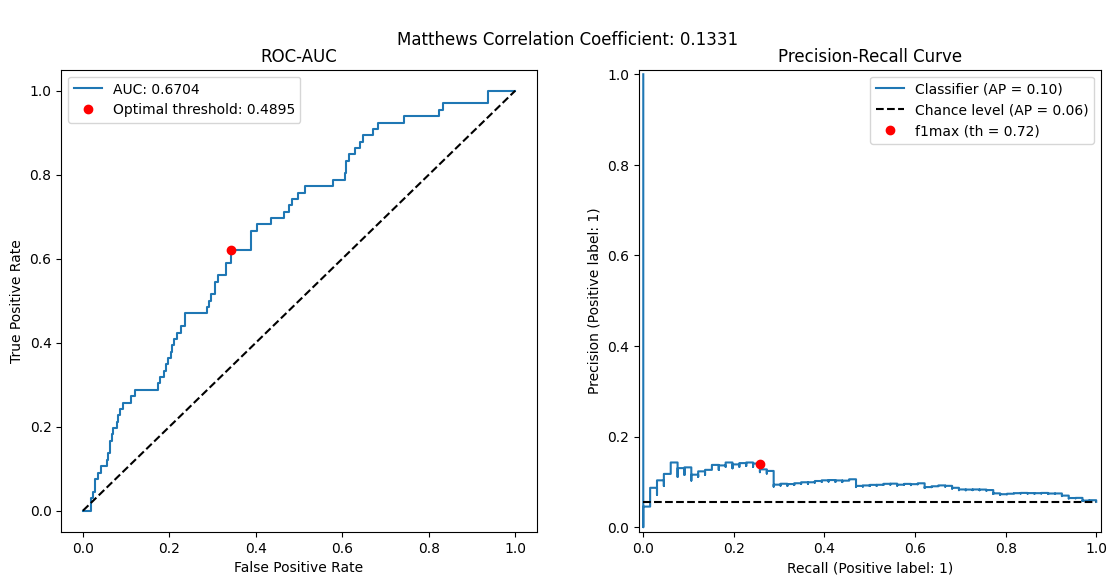

In [ ]:
fig, axs = plt.subplots(1,2, figsize=(13.5, 6))         # create plots for curves

x = np.linspace(0,1)

test_data = pd.read_csv(config.data.test_dataset_file)  # load the test data
test_smiles = test_data[config.data.input_column]       # test structures
y_true = test_data[config.data.response_column]         # test ground truth labels

y_pred = model.predict_from_smiles(test_smiles)         # model predictions on test set structures

plt.subplot(121)

# Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred) # false positive rate, true positive rate and thresholds
auc = np.trapz(tpr, fpr)                                     # AUC using trapezoidal rule
plt.plot(fpr, tpr)                                           # plot the ROC curve
axs[0].set_title('ROC-AUC')

# Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]

x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]

plt.plot(x_coord, y_coord,'ro');

plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

# Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"\nMatthews Correlation Coefficient: {mcc:.4}")   # matthews CC
# print(classification_report(y_true, y_pred_bin))              # classification report
# print(cm(y_true, y_pred_bin))                                 # confusion matrix

# Plotting the Precision-Recall curve

pos_label = 1 
name = "TM-1"

precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)     # precision, recall and thresholds
f1_scores = 2 * recall * precision / (recall + precision)                                       # https://stats.stackexchange.com/questions/596807/how-to-get-the-threshold-from-precisionrecalldisplay
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true=y_true, y_pred=y_pred, pos_label=pos_label, plot_chance_level=True, ax=axs[1])

axs[1].plot(name=name)
axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();